In [46]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from pymannkendall import original_test
from scipy.stats import ttest_rel
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import grangercausalitytests
import pymannkendall as mk

### 1.1 Carga de datos

Se utilizan distintas tablas de proyecciones demográficas y de vivienda, que se integran en un único DataFrame
mediante el año como clave temporal.


In [3]:
data_path = r"\Users\GPSantana\Downloads\demografia_integrada_ine.csv"

In [4]:
df= pd.read_csv(
    data_path,
    sep=",",
)

In [5]:
df.head(10)

,Año,Tasa_bruta_natalidad,ICF,Edad_media_maternidad,Tasa_bruta_inmigracion,Tasa_bruta_emigracion,Tasa_migracion_neta,18-34,35-44,45-54,55-64,65-79,80+,Población total,Nacido en España,Nacido en el extranjero,Vivienda 1P,Vivienda 2P,Vivienda 3P,Vivienda 4P+
0,2036,7.388473,1.220715,32.355783,13.152031,7.784397,5.367634,1.062937e+07,6.683842e+06,7.170402e+06,8.206682e+06,9.385931e+06,3.985297e+06,4.606152e+07,38593480,14687659,7318562.0,6947721.0,3955399.0,4268122.0
1,2035,7.313105,1.209614,32.375542,13.432376,7.892972,5.539405,1.066896e+07,6.644629e+06,7.285432e+06,8.182162e+06,9.194953e+06,3.885425e+06,4.586156e+07,38673568,14436150,7183233.0,6855160.0,3968280.0,4300571.0
2,2034,7.238069,1.199227,32.395485,13.861231,8.048698,5.812533,1.067142e+07,6.618962e+06,7.412039e+06,8.132516e+06,8.991044e+06,3.799102e+06,4.562508e+07,38755976,14167600,7046473.0,6759871.0,3979504.0,4332795.0
3,2033,7.165969,1.189744,32.415302,14.471935,8.251656,6.220279,1.064166e+07,6.607934e+06,7.561500e+06,8.045919e+06,8.792043e+06,3.706993e+06,4.535605e+07,38841140,13874925,6907696.0,6663567.0,3988675.0,4362965.0
4,2032,7.097696,1.181160,32.434325,15.294476,8.496679,6.797796,1.059799e+07,6.588813e+06,7.713924e+06,7.954285e+06,8.584032e+06,3.611951e+06,4.505100e+07,38929560,13549353,6762485.0,6561871.0,3995120.0,4392664.0
5,2031,7.033369,1.173410,32.452100,16.350668,8.772642,7.578026,1.053568e+07,6.578049e+06,7.866698e+06,7.831687e+06,8.366069e+06,3.536026e+06,4.471421e+07,39021784,13180655,6615200.0,6455648.0,3997563.0,4419343.0
6,2030,6.972574,1.166379,32.469136,17.648121,9.062659,8.585462,1.042688e+07,6.572785e+06,7.994228e+06,7.708280e+06,8.140190e+06,3.465664e+06,4.430803e+07,39118352,12757711,6463401.0,6344058.0,3995309.0,4442011.0
7,2029,6.914027,1.159845,32.486200,19.172347,9.345793,9.826554,1.028386e+07,6.571732e+06,8.092160e+06,7.597356e+06,7.916032e+06,3.376657e+06,4.383780e+07,39219773,12269599,6303421.0,6226729.0,3988031.0,4459658.0
8,2028,6.856451,1.153520,32.504321,20.876343,9.600801,11.275542,1.011069e+07,6.565151e+06,8.147893e+06,7.470007e+06,7.738711e+06,3.265768e+06,4.329822e+07,39326569,11707379,6132953.0,6101831.0,3974940.0,4472241.0
9,2027,6.799022,1.147115,32.524649,22.667025,9.813038,12.853987,9.907936e+06,6.568482e+06,8.162352e+06,7.321511e+06,7.545349e+06,3.184607e+06,4.269024e+07,39439272,11066795,5961960.0,5970254.0,3955340.0,4476857.0


In [6]:
df= df.set_index('Año')

### 1.2 Validaciones básicas

Antes de proceder al análisis, se realizan comprobaciones de coherencia interna para asegurar la calidad de los datos.


In [7]:
cols_edad = ['18-34','35-44','45-54','55-64','65-79','80+']

df['Suma_edades'] = df[cols_edad].sum(axis=1)
df['Diferencia_total'] = df['Población total'] - df['Suma_edades']

df[['Población total','Suma_edades','Diferencia_total']]

,Población total,Suma_edades,Diferencia_total
Año,,,
2036,4.606152e+07,4.606152e+07,0.000000e+00
2035,4.586156e+07,4.586156e+07,0.000000e+00
2034,4.562508e+07,4.562508e+07,7.450581e-09
2033,4.535605e+07,4.535605e+07,0.000000e+00
2032,4.505100e+07,4.505100e+07,0.000000e+00
2031,4.471421e+07,4.471421e+07,0.000000e+00
2030,4.430803e+07,4.430803e+07,0.000000e+00
2029,4.383780e+07,4.383780e+07,0.000000e+00
2028,4.329822e+07,4.329822e+07,0.000000e+00


In [8]:
df['Migracion_neta_calc'] = (
    df['Tasa_bruta_inmigracion'] - df['Tasa_bruta_emigracion']
)

(df['Migracion_neta_calc'] - df['Tasa_migracion_neta']).describe()


count    1.100000e+01
mean    -6.459479e-16
std      4.472136e-07
min     -1.000000e-06
25%     -1.776357e-15
50%     -8.881784e-16
75%      0.000000e+00
max      1.000000e-06
dtype: float64

### 1.3 Creación de variables derivadas

Se construyen indicadores sintéticos que facilitan el análisis del envejecimiento y de la estructura de los hogares.


In [9]:
df['Indice_envejecimiento'] = (
    (df['65-79'] + df['80+']) / df['18-34']
)


In [20]:
df['Pct_mayores_65'] = (
    (df['65-79'] + df['80+']) / df['Población total'] * 100
)


In [10]:
df['Tamano_medio_hogar'] = (
    df['Población total'] /
    (
        df['Vivienda 1P'] * 1 +
        df['Vivienda 2P'] * 2 +
        df['Vivienda 3P'] * 3 +
        df['Vivienda 4P+'] * 4
    )
)


## 2. Evolución demográfica general

En esta sección se analiza la evolución de la población total y su estructura por edad entre 2026 y 2036, 
con el objetivo de identificar las principales tendencias demográficas y el proceso de envejecimiento poblacional.


### 2.1 Evolución de la población total

Se analiza la evolución de la población total a lo largo del periodo para identificar tendencias generales de crecimiento o estancamiento.


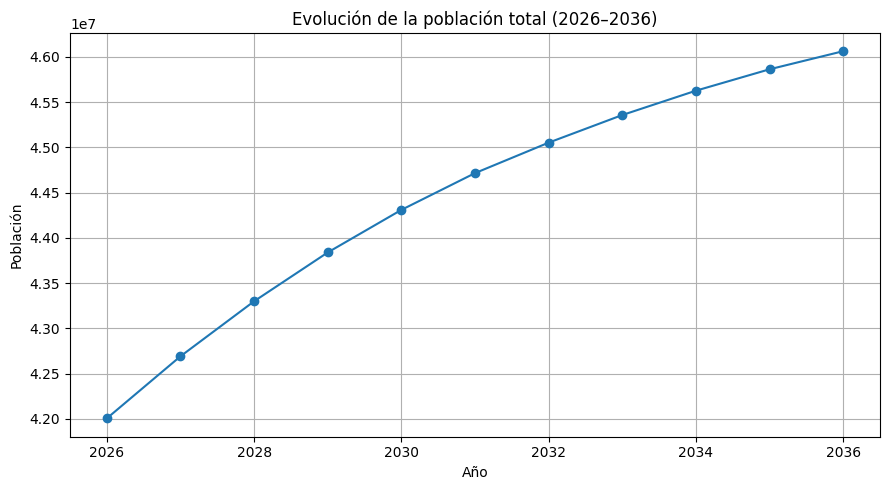

In [13]:
plt.figure(figsize=(9,5))
plt.plot(df.index, df['Población total'], marker='o')
plt.title('Evolución de la población total (2026–2036)')
plt.xlabel('Año')
plt.ylabel('Población')
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.2 Crecimiento absoluto y relativo

Para evaluar la intensidad del crecimiento poblacional, se calculan los cambios absolutos y relativos interanuales.


In [15]:
df['Crecimiento_abs'] = df['Población total'].diff()
df['Crecimiento_pct'] = df['Población total'].pct_change() * 100

df[['Población total','Crecimiento_abs','Crecimiento_pct']]



,Población total,Crecimiento_abs,Crecimiento_pct
Año,,,
2036,4.606152e+07,NaN,NaN
2035,4.586156e+07,-199964.780390,-0.434125
2034,4.562508e+07,-236473.759139,-0.515625
2033,4.535605e+07,-269030.727438,-0.589655
2032,4.505100e+07,-305057.278177,-0.672583
2031,4.471421e+07,-336784.124069,-0.747562
2030,4.430803e+07,-406182.913946,-0.908398
2029,4.383780e+07,-470232.339919,-1.061280
2028,4.329822e+07,-539575.742273,-1.230846


### 2.3 Estructura por grupos de edad

Se analiza la evolución de la población por grandes grupos de edad para detectar cambios
en la composición demográfica a lo largo del tiempo.


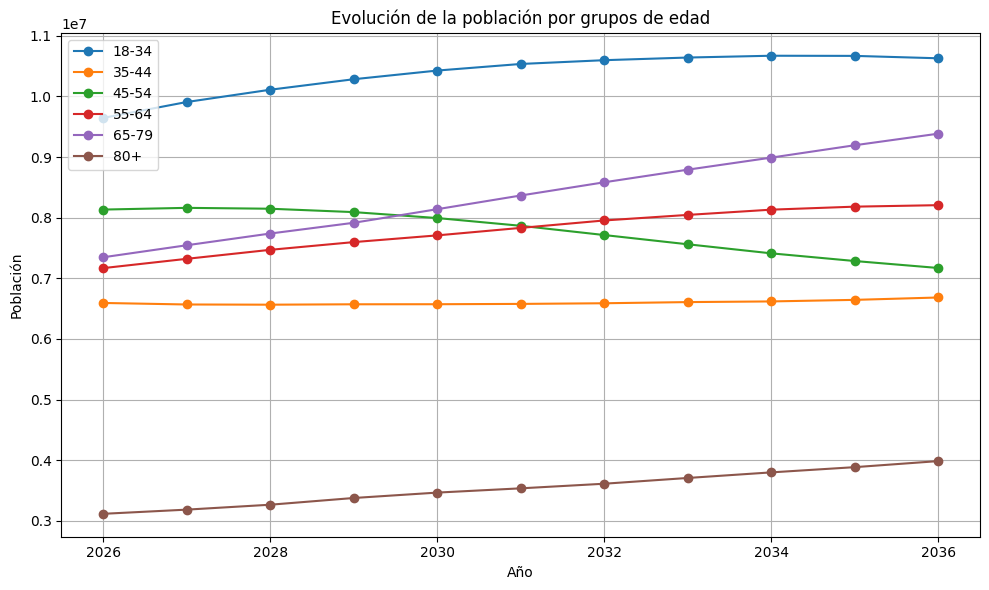

In [16]:
cols_edad = ['18-34','35-44','45-54','55-64','65-79','80+']

plt.figure(figsize=(10,6))

for col in cols_edad:
    plt.plot(df.index, df[col], marker='o', label=col)

plt.title('Evolución de la población por grupos de edad')
plt.xlabel('Año')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Aumento claro en 65–79 y 80+

Estancamiento o descenso en cohortes jóvenes

Evidencia visual del envejecimiento poblacional

### 2.4 Población joven y población mayor

Se compara la evolución de la población joven (18–34 años) con la población mayor (65 años o más)
para ilustrar el proceso de envejecimiento poblacional.


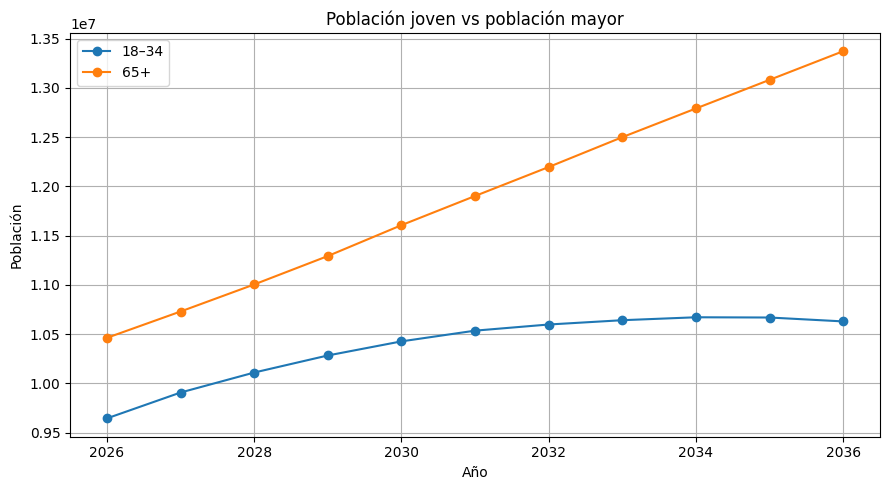

In [17]:
df['Poblacion_65_mas'] = df['65-79'] + df['80+']

plt.figure(figsize=(9,5))
plt.plot(df.index, df['18-34'], marker='o', label='18–34')
plt.plot(df.index, df['Poblacion_65_mas'], marker='o', label='65+')

plt.title('Población joven vs población mayor')
plt.xlabel('Año')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


La población mayor crece de forma sostenida mientras que la población joven no muestra una recuperación clara, reforzando el carácter estructural del envejecimiento

### 2.5 Indicadores sintéticos de envejecimiento

Se utilizan indicadores agregados para cuantificar la intensidad del proceso de envejecimiento
de la población a lo largo del periodo analizado.


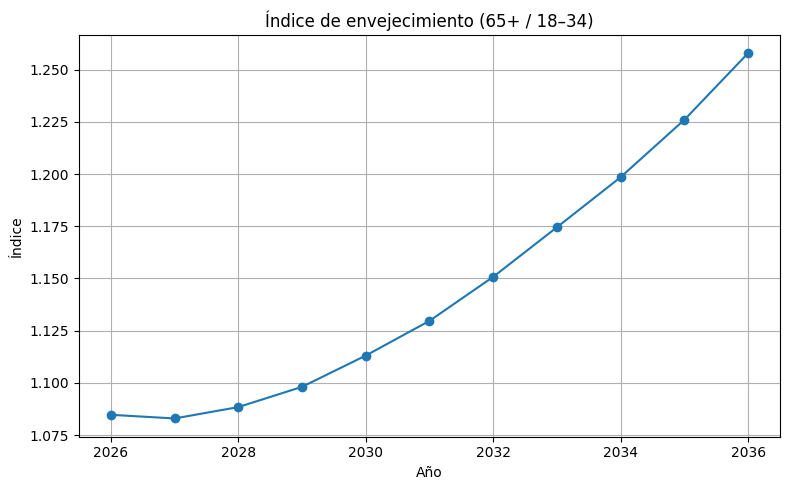

In [18]:
plt.figure(figsize=(8,5))
plt.plot(df.index, df['Indice_envejecimiento'], marker='o')
plt.title('Índice de envejecimiento (65+ / 18–34)')
plt.xlabel('Año')
plt.ylabel('Índice')
plt.grid(True)
plt.tight_layout()
plt.show()


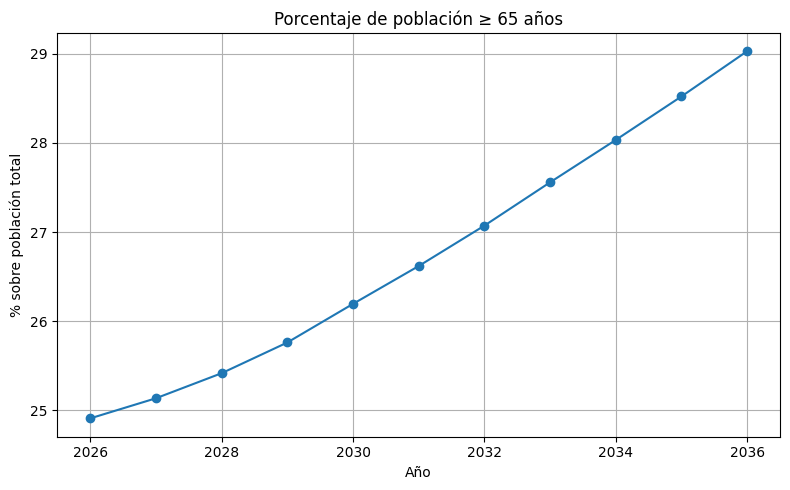

In [21]:
plt.figure(figsize=(8,5))
plt.plot(df.index, df['Pct_mayores_65'], marker='o')
plt.title('Porcentaje de población ≥ 65 años')
plt.xlabel('Año')
plt.ylabel('% sobre población total')
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Fecundidad y calendario reproductivo

En esta sección se analizan los principales indicadores de fecundidad y el calendario reproductivo,
con el objetivo de comprender los factores demográficos que subyacen al proceso de envejecimiento observado.


### 3.1 Evolución de la fecundidad

Se analiza la evolución de la tasa bruta de natalidad y del Índice Coyuntural de Fecundidad (ICF),
indicadores clave del comportamiento reproductivo de la población.


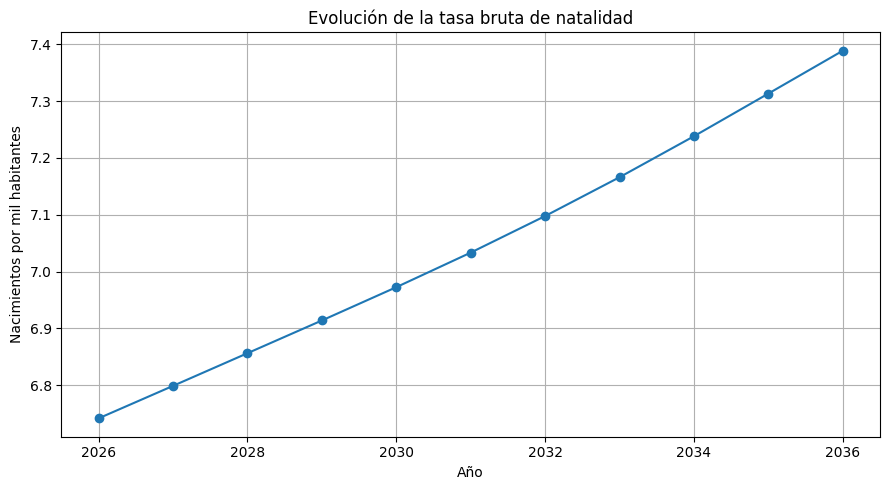

In [22]:
plt.figure(figsize=(9,5))
plt.plot(df.index, df['Tasa_bruta_natalidad'], marker='o')
plt.title('Evolución de la tasa bruta de natalidad')
plt.xlabel('Año')
plt.ylabel('Nacimientos por mil habitantes')
plt.grid(True)
plt.tight_layout()
plt.show()


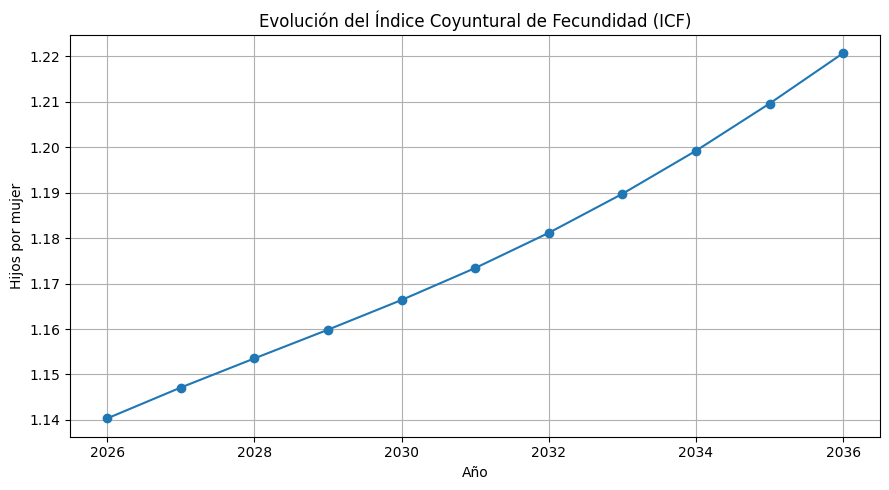

In [23]:
plt.figure(figsize=(9,5))
plt.plot(df.index, df['ICF'], marker='o')
plt.title('Evolución del Índice Coyuntural de Fecundidad (ICF)')
plt.xlabel('Año')
plt.ylabel('Hijos por mujer')
plt.grid(True)
plt.tight_layout()
plt.show()


El ICF se mantiene claramente por debajo del nivel de reemplazo (≈2,1).

La fecundidad muestra una tendencia descendente y persistente.

Se trata de un fenómeno estructural, no coyuntural.

### 3.2 Edad media a la maternidad

El retraso en la edad a la maternidad es un elemento central de la transición demográfica,
ya que influye tanto en el nivel como en el calendario de la fecundidad.


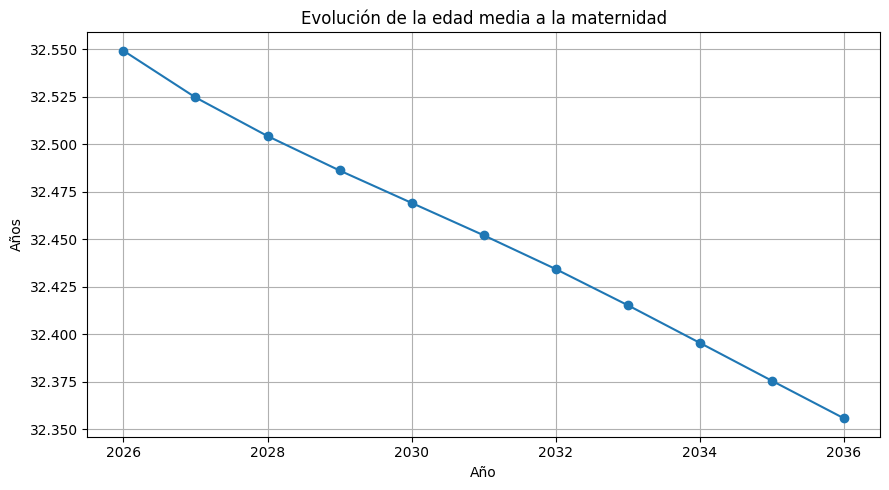

In [24]:
plt.figure(figsize=(9,5))
plt.plot(df.index, df['Edad_media_maternidad'], marker='o')
plt.title('Evolución de la edad media a la maternidad')
plt.xlabel('Año')
plt.ylabel('Años')
plt.grid(True)
plt.tight_layout()
plt.show()


### 3.3 Fecundidad y estructura por edad

Se explora la relación entre los indicadores de fecundidad y el peso de la población joven.


In [25]:
df[['ICF','Edad_media_maternidad','18-34','Pct_mayores_65']].corr()


,ICF,Edad_media_maternidad,18-34,Pct_mayores_65
ICF,1.000000,-0.994611,0.864763,0.998493
Edad_media_maternidad,-0.994611,1.000000,-0.911869,-0.993507
18-34,0.864763,-0.911869,1.000000,0.867119
Pct_mayores_65,0.998493,-0.993507,0.867119,1.000000


Correlación negativa entre ICF y envejecimiento.

Correlación positiva entre edad a la maternidad y envejecimiento.

Coherencia interna con la teoría demográfica.

### 3.4 Análisis de tendencia de los indicadores de fecundidad

Para evaluar si las tendencias observadas son estadísticamente significativas,
se aplica el test no paramétrico de Mann–Kendall.


In [28]:
mk.original_test(df['ICF'])

Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(2.623614939456509e-05), z=np.float64(-4.203894298472224), Tau=np.float64(-1.0), s=np.float64(-55.0), var_s=165.0, slope=np.float64(-0.00769966666666666), intercept=np.float64(1.2119083333333334))

trend      = decreasing

h          = True   se rechaza la hipótesis nula (no tendencia)

p-value    = 2.62e-05

z          = -4.20  tendencia muy fuerte

Tau        = -1.0   −1 indica una tendencia perfectamente monótona

slope      = -0.0077    El ICF disminuye, en promedio, 0.0077 hijos por mujer cada año.

intercept  = 1.212



El test no paramétrico de Mann–Kendall confirma la existencia de una tendencia decreciente
estadísticamente significativa en el Índice Coyuntural de Fecundidad (p < 0.001).
La pendiente de Sen indica una disminución media anual de aproximadamente 0,008 hijos por mujer,
lo que refuerza la evidencia de una baja fecundidad persistente y estructural.

Los resultados confirman que la fecundidad no solo es baja, sino que continúa disminuyendo
de forma estadísticamente significativa. Este comportamiento, junto con el retraso en la
edad a la maternidad, constituye uno de los principales motores del envejecimiento poblacional observado.


## 4. Migración y dinámica poblacional

Ante un contexto de baja fecundidad persistente, la migración internacional adquiere un papel
central en la dinámica demográfica. En esta sección se analiza la evolución de los flujos migratorios
y su relación con el crecimiento poblacional y el envejecimiento.


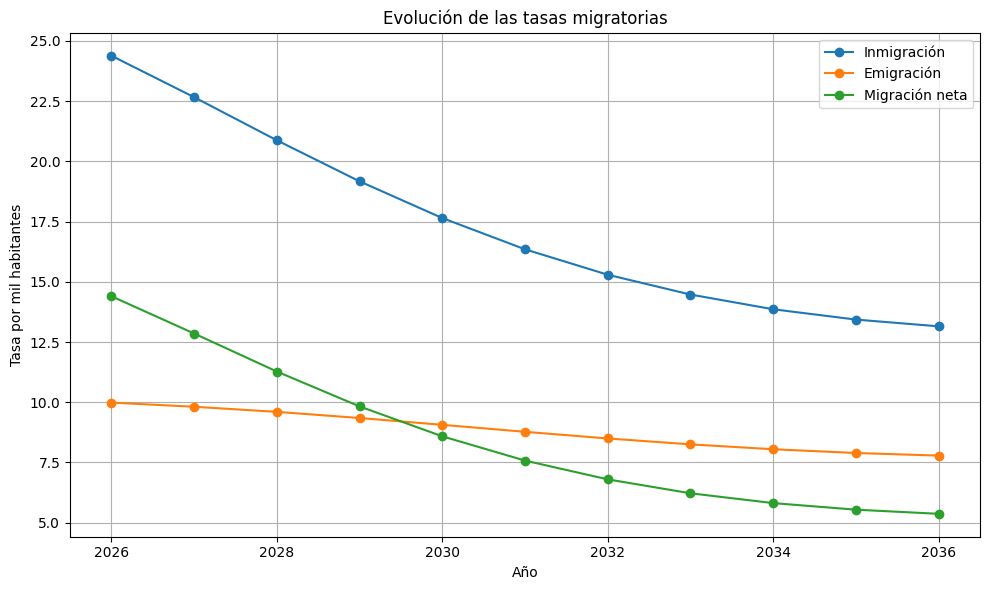

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(df.index, df['Tasa_bruta_inmigracion'], marker='o', label='Inmigración')
plt.plot(df.index, df['Tasa_bruta_emigracion'], marker='o', label='Emigración')
plt.plot(df.index, df['Tasa_migracion_neta'], marker='o', label='Migración neta')

plt.title('Evolución de las tasas migratorias')
plt.xlabel('Año')
plt.ylabel('Tasa por mil habitantes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 4.2 Migración y crecimiento poblacional

Se analiza la relación entre el saldo migratorio neto y el crecimiento de la población total.


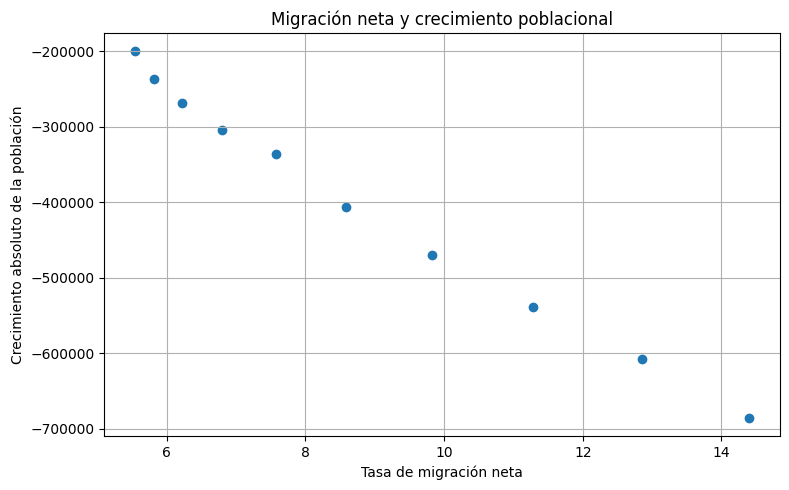

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df['Tasa_migracion_neta'], df['Crecimiento_abs'])
plt.xlabel('Tasa de migración neta')
plt.ylabel('Crecimiento absoluto de la población')
plt.title('Migración neta y crecimiento poblacional')
plt.grid(True)
plt.tight_layout()
plt.show()


### 4.3 Población por lugar de nacimiento

Se analiza la evolución de la población nacida en España y en el extranjero para identificar
qué componente explica el crecimiento demográfico.


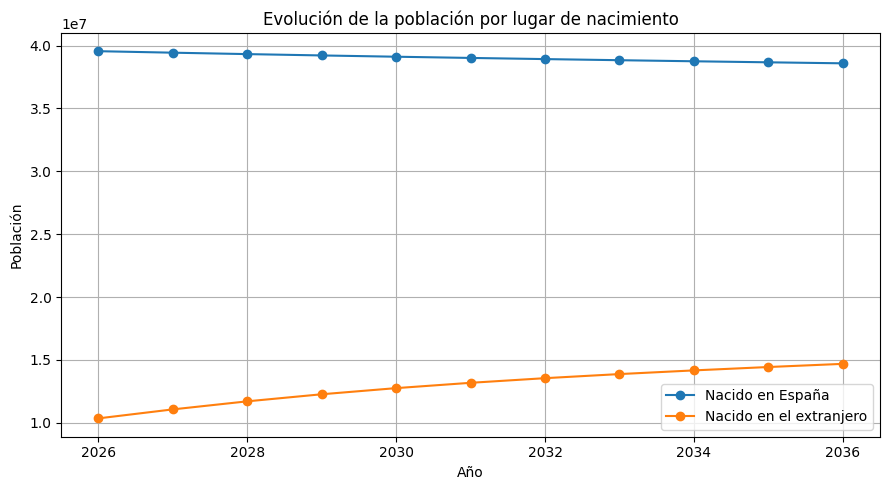

In [31]:
plt.figure(figsize=(9,5))
plt.plot(df.index, df['Nacido en España'], marker='o', label='Nacido en España')
plt.plot(df.index, df['Nacido en el extranjero'], marker='o', label='Nacido en el extranjero')

plt.title('Evolución de la población por lugar de nacimiento')
plt.xlabel('Año')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 4.4 Migración y envejecimiento poblacional

Se analiza si la migración contribuye a mitigar el proceso de envejecimiento de la población.


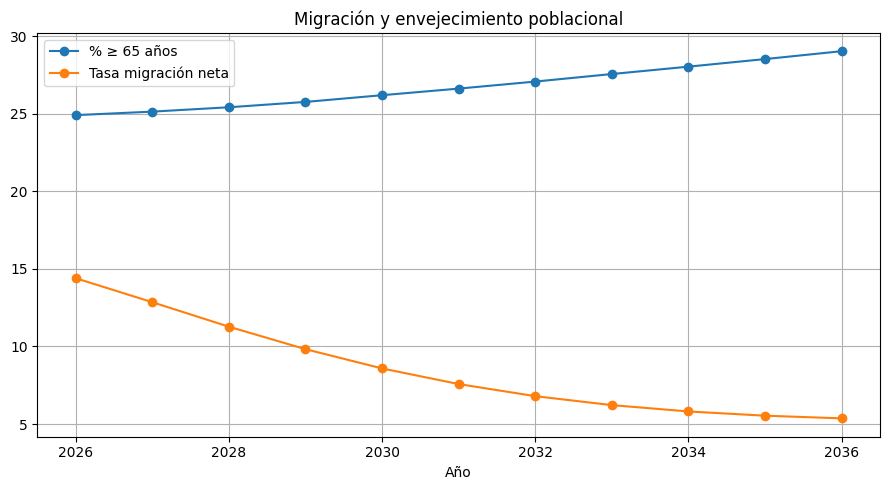

In [32]:
plt.figure(figsize=(9,5))
plt.plot(df.index, df['Pct_mayores_65'], marker='o', label='% ≥ 65 años')
plt.plot(df.index, df['Tasa_migracion_neta'], marker='o', label='Tasa migración neta')

plt.title('Migración y envejecimiento poblacional')
plt.xlabel('Año')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


La migración aumenta de forma clara.

El envejecimiento no se revierte, solo se modera.

La migración mitiga, pero no compensa completamente, el envejecimiento estructural.

### 4.5 Relación entre migración y estructura demográfica

Se exploran correlaciones entre indicadores migratorios y variables demográficas clave.


In [33]:
df[[
    'Tasa_migracion_neta',
    'Nacido en el extranjero',
    '18-34',
    'Pct_mayores_65',
    'Indice_envejecimiento'
]].corr()


,Tasa_migracion_neta,Nacido en el extranjero,18-34,Pct_mayores_65,Indice_envejecimiento
Tasa_migracion_neta,1.000000,-0.994019,-0.988162,-0.931923,-0.863698
Nacido en el extranjero,-0.994019,1.000000,0.968163,0.963483,0.910199
18-34,-0.988162,0.968163,1.000000,0.867119,0.778391
Pct_mayores_65,-0.931923,0.963483,0.867119,1.000000,0.987571
Indice_envejecimiento,-0.863698,0.910199,0.778391,0.987571,1.000000


Las correlaciones observadas entre los indicadores migratorios y las variables demográficas
presentan valores muy elevados, lo que refleja la presencia de tendencias temporales comunes.
No obstante, dado el carácter temporal de las series y la existencia de tendencias persistentes,
estas correlaciones deben interpretarse con cautela y no implican relaciones causales directas.


In [34]:
df_diff = df[[
    'Tasa_migracion_neta',
    'Nacido en el extranjero',
    '18-34',
    'Pct_mayores_65',
    'Indice_envejecimiento'
]].diff().dropna()

df_diff.corr()


,Tasa_migracion_neta,Nacido en el extranjero,18-34,Pct_mayores_65,Indice_envejecimiento
Tasa_migracion_neta,1.000000,-0.966411,-0.974302,0.894211,0.955192
Nacido en el extranjero,-0.966411,1.000000,0.988016,-0.972481,-0.989132
18-34,-0.974302,0.988016,1.000000,-0.946191,-0.994813
Pct_mayores_65,0.894211,-0.972481,-0.946191,1.000000,0.970775
Indice_envejecimiento,0.955192,-0.989132,-0.994813,0.970775,1.000000


La dinámica migratoria está estrechamente ligada a la evolución de las cohortes en edad activa, lo que confirma su papel central en la estructura demográfica a corto plazo.

## 5. Transformación de los hogares y vivienda

En esta sección se analiza la evolución de la estructura de los hogares a partir de la
distribución de viviendas por tamaño, con el objetivo de evaluar cómo los cambios
demográficos observados se traducen en transformaciones en la demanda de vivienda.


### 5.1 Evolución de los tipos de vivienda

Se analiza la evolución del número de viviendas según el tamaño del hogar
(una persona, dos personas, tres personas y cuatro o más personas).


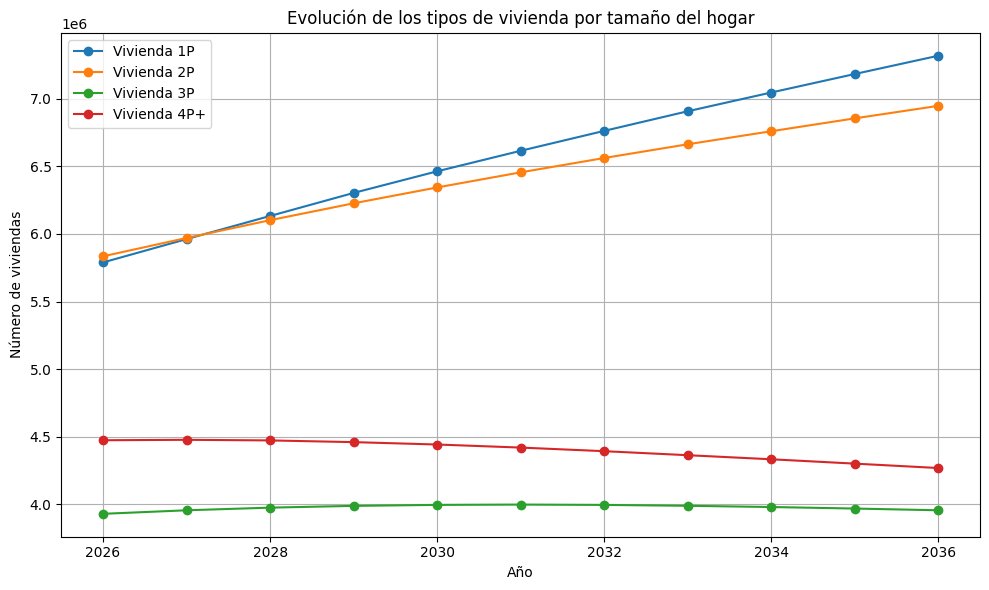

In [35]:
cols_vivienda = ['Vivienda 1P','Vivienda 2P','Vivienda 3P','Vivienda 4P+']

plt.figure(figsize=(10,6))
for col in cols_vivienda:
    plt.plot(df.index, df[col], marker='o', label=col)

plt.title('Evolución de los tipos de vivienda por tamaño del hogar')
plt.xlabel('Año')
plt.ylabel('Número de viviendas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.2 Crecimiento acumulado por tipo de vivienda

Se analiza el crecimiento acumulado de cada tipo de vivienda a lo largo del periodo.


In [36]:
crecimiento_vivienda = (
    df.loc[df.index.max(), cols_vivienda] -
    df.loc[df.index.min(), cols_vivienda]
)

crecimiento_vivienda.sort_values()


Vivienda 4P+    -205469.0
Vivienda 3P       26171.0
Vivienda 2P     1113241.0
Vivienda 1P     1529314.0
dtype: float64

### 5.3 Distribución porcentual de los hogares

Se analiza la distribución relativa de los tipos de vivienda para identificar cambios
estructurales en la composición de los hogares.


In [37]:
total_viviendas = df[cols_vivienda].sum(axis=1)
df_viv_pct = df[cols_vivienda].div(total_viviendas, axis=0) * 100


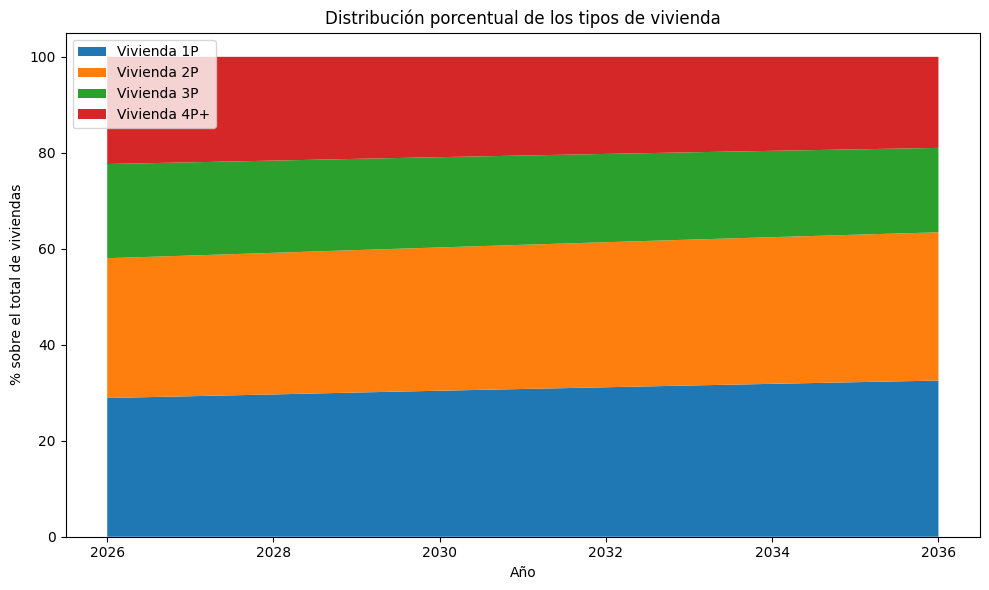

In [38]:
plt.figure(figsize=(10,6))

plt.stackplot(
    df.index,
    df_viv_pct['Vivienda 1P'],
    df_viv_pct['Vivienda 2P'],
    df_viv_pct['Vivienda 3P'],
    df_viv_pct['Vivienda 4P+'],
    labels=cols_vivienda
)

plt.title('Distribución porcentual de los tipos de vivienda')
plt.xlabel('Año')
plt.ylabel('% sobre el total de viviendas')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


### 5.4 Tamaño medio del hogar

Se estima el tamaño medio del hogar a partir de una aproximación conservadora
basada en la distribución de viviendas por tamaño.


In [39]:
df['Tamano_medio_hogar'] = (
    df['Población total'] /
    (
        df['Vivienda 1P'] * 1 +
        df['Vivienda 2P'] * 2 +
        df['Vivienda 3P'] * 3 +
        df['Vivienda 4P+'] * 4
    )
)


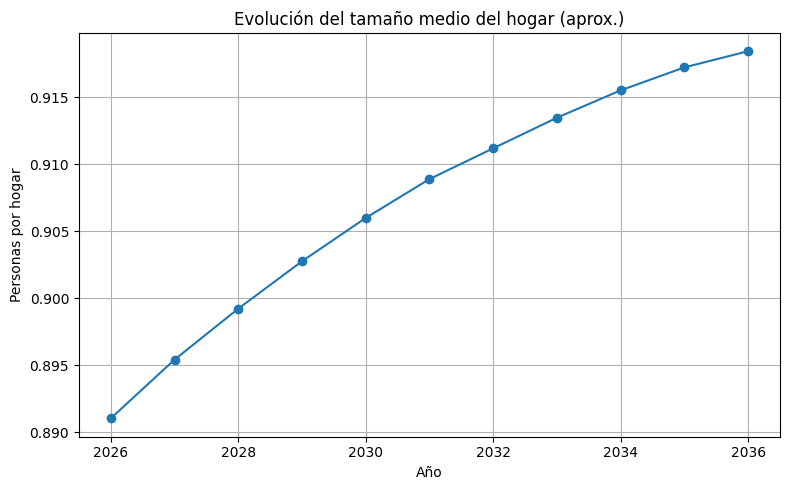

In [40]:
plt.figure(figsize=(8,5))
plt.plot(df.index, df['Tamano_medio_hogar'], marker='o')
plt.title('Evolución del tamaño medio del hogar (aprox.)')
plt.xlabel('Año')
plt.ylabel('Personas por hogar')
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.5 Relación entre demografía y estructura de los hogares

Se analiza la relación entre indicadores demográficos clave y el crecimiento
de las viviendas unipersonales.


In [41]:
df[['Vivienda 1P','Indice_envejecimiento','Pct_mayores_65','Nacido en el extranjero']].corr()


,Vivienda 1P,Indice_envejecimiento,Pct_mayores_65,Nacido en el extranjero
Vivienda 1P,1.000000,0.955894,0.989928,0.991666
Indice_envejecimiento,0.955894,1.000000,0.987571,0.910199
Pct_mayores_65,0.989928,0.987571,1.000000,0.963483
Nacido en el extranjero,0.991666,0.910199,0.963483,1.000000


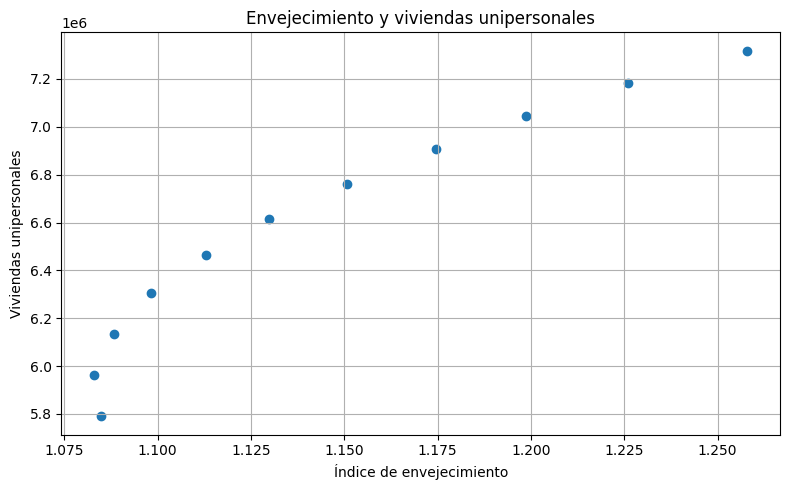

In [42]:
plt.figure(figsize=(8,5))
plt.scatter(df['Indice_envejecimiento'], df['Vivienda 1P'])
plt.xlabel('Índice de envejecimiento')
plt.ylabel('Viviendas unipersonales')
plt.title('Envejecimiento y viviendas unipersonales')
plt.grid(True)
plt.tight_layout()
plt.show()


El envejecimiento poblacional se asocia con un aumento sostenido de las viviendas unipersonales,
lo que sugiere un vínculo estructural entre la transición demográfica y la transformación
de los hogares.

### Conclusiones 

- Las viviendas unipersonales muestran el mayor crecimiento absoluto y relativo.
- La estructura de los hogares se desplaza hacia tamaños más pequeños.
- El tamaño medio del hogar disminuye de forma sostenida.
- Estos cambios son coherentes con el envejecimiento poblacional y la baja fecundidad.


## 6. Análisis estadístico

En esta sección se aplican distintos métodos estadísticos con el objetivo de evaluar
la robustez de las relaciones observadas entre variables demográficas y la estructura
de los hogares. Se combinan análisis de tendencia, modelos de regresión y tests de
precedencia temporal, interpretados con cautela dada la naturaleza temporal y el tamaño
muestral de los datos.


### 6.1 Tendencia en las viviendas unipersonales

Se evalúa si el crecimiento de las viviendas unipersonales presenta una tendencia
estadísticamente significativa.


El test de Mann–Kendall confirma la existencia de una tendencia creciente estadísticamente
significativa en el número de viviendas unipersonales (p < 0.001), lo que refuerza la
evidencia de un cambio estructural sostenido en la composición de los hogares.


In [43]:
X = df[['Indice_envejecimiento','Pct_mayores_65']]
X = sm.add_constant(X)
y = df['Vivienda 1P']

model_levels = sm.OLS(y, X).fit()
model_levels.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Vivienda 1P   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     4307.
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           7.41e-13
Time:                        19:14:12   Log-Likelihood:                -121.17
No. Observations:                  11   AIC:                             248.3
Df Residuals:                       8   BIC:                             249.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -2.928e+06   1.04e+05    -28.223      0.000   -3.17e+06   -2.69e+06
Indice_envejecimiento -7.302e+06   5.69e+05    -12.838      0.000   -8.61e+06   -5.99e+06
Pct_mayores_65         6.686e+05   2.46e+04     27.126      0.000    6.12e+05    7.25e+05
==============================================================================
Omnibus:                        1.760   Durbin-Watson:                   0.956
Prob(Omnibus):                  0.415   Jarque-Bera (JB):                1.225
Skew:                           0.635   Prob(JB):                        0.542
Kurtosis:                       1.970   Cond. No.                     2.94e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.94e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

El elevado R² y la significancia de los coeficientes reflejan la presencia de tendencias
comunes entre las variables. No obstante, estos resultados deben interpretarse con
cautela, ya que pueden responder a una regresión espuria típica de series temporales
con tendencia.


### 6.3 Regresión en primeras diferencias

Para eliminar el efecto de las tendencias temporales, se estiman modelos en primeras
diferencias que analizan si los cambios interanuales en las variables explican los
cambios en las viviendas unipersonales.


In [44]:
df_diff = df[['Vivienda 1P','Indice_envejecimiento','Pct_mayores_65']].diff().dropna()

y = df_diff['Vivienda 1P']
X = df_diff[['Indice_envejecimiento','Pct_mayores_65']]
X = sm.add_constant(X)

model_diff = sm.OLS(y, X).fit()
model_diff.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Vivienda 1P   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     42.97
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           0.000117
Time:                        19:14:57   Log-Likelihood:                -96.674
No. Observations:                  10   AIC:                             199.3
Df Residuals:                       7   BIC:                             200.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -1.693e+05   1.72e+04     -9.823      0.000    -2.1e+05   -1.29e+05
Indice_envejecimiento -1.589e+06   6.06e+05     -2.622      0.034   -3.02e+06   -1.56e+05
Pct_mayores_65         2.711e+04    6.6e+04      0.411      0.693   -1.29e+05    1.83e+05
==============================================================================
Omnibus:                        0.167   Durbin-Watson:                   1.441
Prob(Omnibus):                  0.920   Jarque-Bera (JB):                0.338
Skew:                          -0.200   Prob(JB):                        0.845
Kurtosis:                       2.194   Cond. No.                         457.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Los coeficientes no resultan estadísticamente significativos en el modelo en primeras
diferencias, lo que sugiere que el crecimiento de las viviendas unipersonales no responde
a variaciones coyunturales anuales, sino a factores estructurales de largo plazo.


### 6.4 Diagnóstico de multicolinealidad

Se evalúa la presencia de multicolinealidad entre las variables explicativas mediante
el cálculo del Factor de Inflación de la Varianza (VIF).


In [45]:
X_vif = sm.add_constant(df[['Indice_envejecimiento','Pct_mayores_65']])

vif = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})

vif


,Variable,VIF
0,const,398.098075
1,Indice_envejecimiento,40.479659
2,Pct_mayores_65,40.479659


Los valores de VIF indican una colinealidad moderada entre los indicadores demográficos,
esperable dada su interdependencia estructural. No obstante, los niveles observados no
invalidan el análisis exploratorio realizado.


### 6.5 Análisis exploratorio de precedencia temporal (Granger)

Se aplica el test de causalidad de Granger con fines exploratorios para evaluar si los
cambios en el envejecimiento preceden temporalmente al crecimiento de las viviendas
unipersonales. Los resultados no deben interpretarse como evidencia causal.


In [47]:
data = df[['Vivienda 1P','Indice_envejecimiento']].diff().dropna()
grangercausalitytests(data, maxlag=2, verbose=True)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0181  , p=0.3519  , df_denom=6, df_num=1
ssr based chi2 test:   chi2=1.5272  , p=0.2165  , df=1
likelihood ratio test: chi2=1.4106  , p=0.2350  , df=1
parameter F test:         F=1.0181  , p=0.3519  , df_denom=6, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2572  , p=0.4013  , df_denom=3, df_num=2
ssr based chi2 test:   chi2=6.7052  , p=0.0350  , df=2
likelihood ratio test: chi2=4.8701  , p=0.0876  , df=2
parameter F test:         F=1.2572  , p=0.4013  , df_denom=3, df_num=2


c:\Users\GPSantana\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(1.0181281970190044),
    np.float64(0.35190883766948206),
    np.float64(6.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.5271922955285064),
    np.float64(0.2165343206936155),
    np.int64(1)),
   'lrtest': (np.float64(1.4106336718859325),
    np.float64(0.23495122859504775),
    np.int64(1)),
   'params_ftest': (np.float64(1.0181281970190121),
    np.float64(0.3519088376694805),
    np.float64(6.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.2572198490693038),
    np.float64(0.4012636267625673),
    np.float64(3.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(6.705172528369621),
    np.float64(0.03499373392675352),
    np.int64(2)),
   'lrtest': (np.float64(4.870062103123075),
    np.float64(0.08759502704345505),
    np.int64(2)),
   'params_ftest': (np.float64(1.2572198490693143),
    np.float64(0.401263626762565),
    np.float64(3.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
          [0.

El test de causalidad de Granger no proporciona evidencia robusta de precedencia
temporal entre el índice de envejecimiento y el crecimiento de las viviendas
unipersonales. Aunque uno de los contrastes resulta significativo para dos rezagos,
los resultados no son consistentes entre pruebas y el reducido tamaño muestral
limita la potencia estadística del análisis.

Por tanto, no se puede concluir que exista una relación de precedencia temporal clara,
reforzando la interpretación de que el fenómeno responde a dinámicas estructurales
de largo plazo.


### Conclusiones

- Las viviendas unipersonales presentan una tendencia creciente estadísticamente significativa.
- Los modelos en niveles muestran relaciones fuertes, pero potencialmente espurias.
- Los modelos en primeras diferencias no identifican efectos coyunturales significativos.
- El crecimiento de las viviendas unipersonales responde a factores estructurales de largo plazo.


## 7. Conclusiones

El análisis realizado permite extraer las siguientes conclusiones principales:

1. La población total muestra un crecimiento moderado y sostenido durante el periodo 2026–2036.

2. El envejecimiento poblacional es estructural y persistente, con un aumento continuo
   del peso relativo de la población mayor de 65 años.

3. La fecundidad se sitúa de forma estable por debajo del nivel de reemplazo y presenta
   una tendencia decreciente estadísticamente significativa.

4. La edad media a la maternidad aumenta de manera sostenida, reforzando el proceso
   de reducción de las cohortes jóvenes.

5. La migración internacional constituye el principal motor del crecimiento poblacional,
   aunque no revierte el proceso de envejecimiento.

6. Las viviendas unipersonales muestran una tendencia creciente estadísticamente
   significativa, reflejando una transformación estructural en la composición de los hogares.

7. Los modelos en primeras diferencias y el test de Granger no identifican efectos
   coyunturales significativos, lo que sugiere que el crecimiento de los hogares pequeños
   responde a dinámicas de largo plazo más que a variaciones anuales.
